# Notebook 05: Validation and Results Analysis

**Purpose**: Comprehensive evaluation of both anomaly detection models for thesis presentation.

**Contents**:
1. Classification metrics (precision, recall, F1) for both models
2. Threshold sensitivity analysis for the autoencoder
3. Deep-dive into sick animal timelines with behavioral context
4. False positive analysis — why were healthy animals flagged?
5. Model comparison summary table
6. Discussion points for thesis

**Input**: `anomaly_results.csv`, `daily_features.csv`  
**Output**: Thesis-ready figures (`fig13`–`fig17`) and summary tables

In [ ]:
# --- Colab Setup (run this cell first if using Google Colab) ---
import os, sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('/content/cattle-anomaly-detection'):
        !git clone https://github.com/dimvsh/cattle-anomaly-detection.git /content/cattle-anomaly-detection
    os.chdir('/content/cattle-anomaly-detection/notebooks')
    !pip install -q -r /content/cattle-anomaly-detection/requirements.txt
    print("Colab setup complete.")
else:
    print("Running locally.")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (12, 6)

PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data', 'processed')
FIGURES_DIR = os.path.join(PROJECT_DIR, 'figures')

df = pd.read_csv(os.path.join(PROCESSED_DIR, 'anomaly_results.csv'), parse_dates=['date'])
df['tag_short'] = df['tag_short'].astype(str)
df['is_sick'] = df['is_sick'].fillna(0).astype(int)

# Sick animals with data
sick_tags = ['1129', '1149']
colors = {'1129': '#e74c3c', '1149': '#2980b9'}
labels = {'1129': 'Animal 1129 (pneumonia)', '1149': 'Animal 1149 (bloat)'}

# Split info
train = df[df['split'] == 'train']
test = df[df['split'] == 'test']

print(f"Loaded: {len(df)} animal-days ({len(train)} train, {len(test)} test)")
print(f"Sick animal-days: {df['is_sick'].sum()} (train: {train['is_sick'].sum()}, test: {test['is_sick'].sum()})")

Loaded: 793 animal-days (527 train, 266 test)
Sick animal-days: 49 (train: 35, test: 14)


## 1. Classification Metrics

We evaluate both models as binary classifiers where `is_sick` is the ground truth label. Note that this is an **imperfect ground truth**: the label marks all days for a sick animal as positive, even though behavioral changes may only appear on some days.

In [2]:
# Classification metrics for both models, overall and test-only
def compute_metrics(y_true, y_pred, label):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n--- {label} ---")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    print(f"  Precision: {precision:.3f}  (of flagged days, how many were truly sick)")
    print(f"  Recall:    {recall:.3f}  (of sick days, how many were flagged)")
    print(f"  F1 Score:  {f1:.3f}")
    return {'model': label, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            'precision': precision, 'recall': recall, 'f1': f1}

results = []
print("=== OVERALL (all 793 animal-days) ===")
results.append(compute_metrics(df['is_sick'], df['ae_anomaly'], 'Autoencoder (overall)'))
results.append(compute_metrics(df['is_sick'], df['if_anomaly'], 'Isolation Forest (overall)'))

print("\n=== TEST PERIOD ONLY (266 animal-days) ===")
results.append(compute_metrics(test['is_sick'], test['ae_anomaly'], 'Autoencoder (test)'))
results.append(compute_metrics(test['is_sick'], test['if_anomaly'], 'Isolation Forest (test)'))

metrics_df = pd.DataFrame(results)
print("\n" + metrics_df.to_string(index=False))

=== OVERALL (all 793 animal-days) ===

--- Autoencoder (overall) ---
  TP=6  FP=26  FN=43  TN=718
  Precision: 0.188  (of flagged days, how many were truly sick)
  Recall:    0.122  (of sick days, how many were flagged)
  F1 Score:  0.148

--- Isolation Forest (overall) ---
  TP=12  FP=101  FN=37  TN=643
  Precision: 0.106  (of flagged days, how many were truly sick)
  Recall:    0.245  (of sick days, how many were flagged)
  F1 Score:  0.148

=== TEST PERIOD ONLY (266 animal-days) ===

--- Autoencoder (test) ---
  TP=2  FP=1  FN=12  TN=251
  Precision: 0.667  (of flagged days, how many were truly sick)
  Recall:    0.143  (of sick days, how many were flagged)
  F1 Score:  0.235

--- Isolation Forest (test) ---
  TP=3  FP=6  FN=11  TN=246
  Precision: 0.333  (of flagged days, how many were truly sick)
  Recall:    0.214  (of sick days, how many were flagged)
  F1 Score:  0.261

                     model  TP  FP  FN  TN  precision   recall       f1
     Autoencoder (overall)   6  26  4

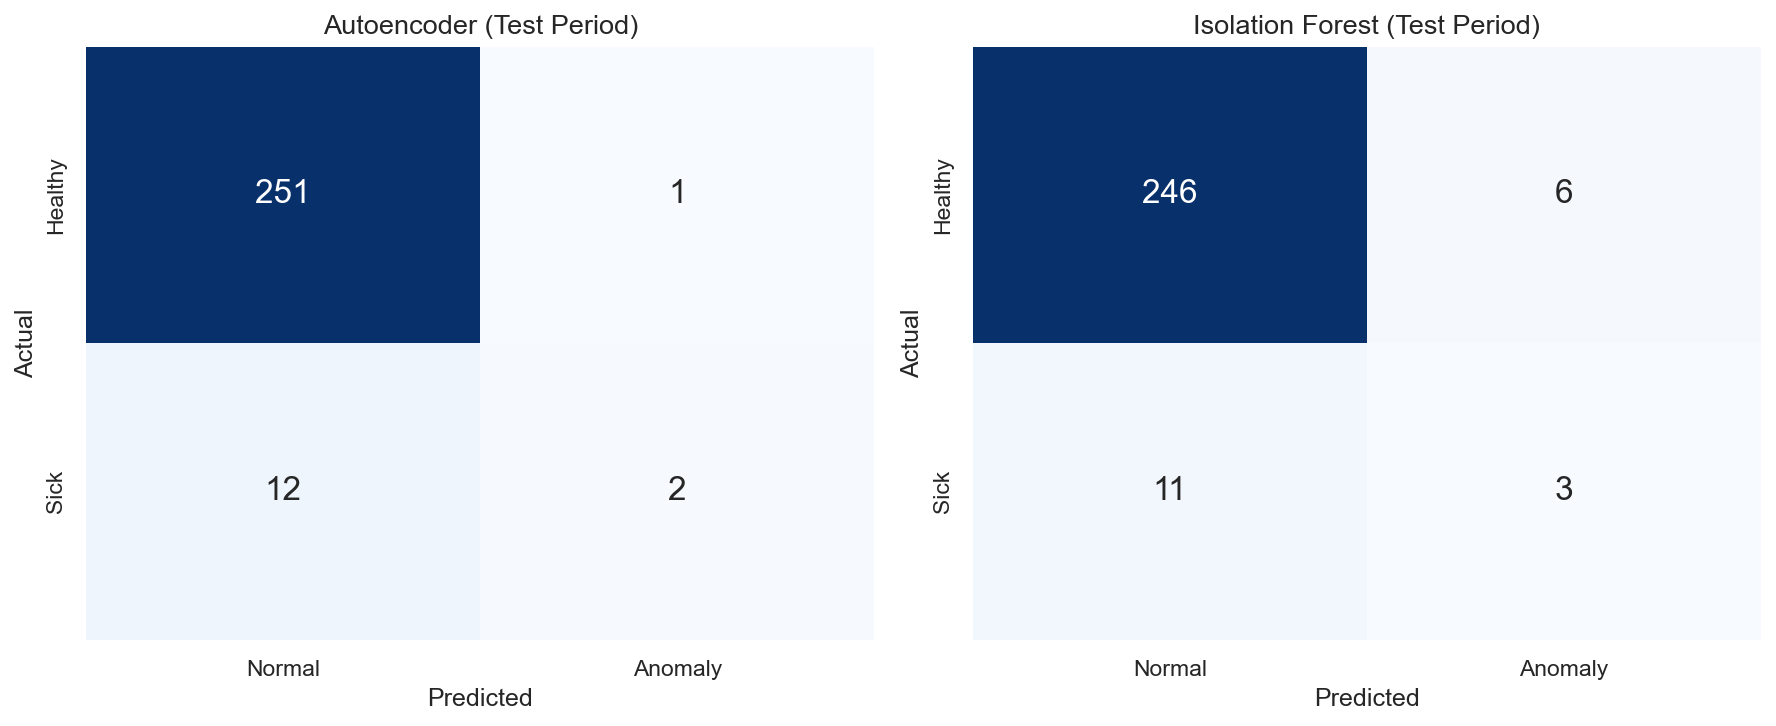

Saved: fig13_confusion_matrices.png


In [3]:
# Fig 13: Confusion matrices — both models, test period
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (pred_col, title) in zip(axes, [
    ('ae_anomaly', 'Autoencoder (Test Period)'),
    ('if_anomaly', 'Isolation Forest (Test Period)')
]):
    cm = confusion_matrix(test['is_sick'], test[pred_col])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Anomaly'], yticklabels=['Healthy', 'Sick'],
                cbar=False, annot_kws={'size': 16})
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(title, fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig13_confusion_matrices.png'), bbox_inches='tight')
plt.show()
print("Saved: fig13_confusion_matrices.png")

## 2. Threshold Sensitivity Analysis

The autoencoder threshold (95th percentile of training errors) directly controls the precision–recall trade-off. We examine how detection performance changes across a range of thresholds.

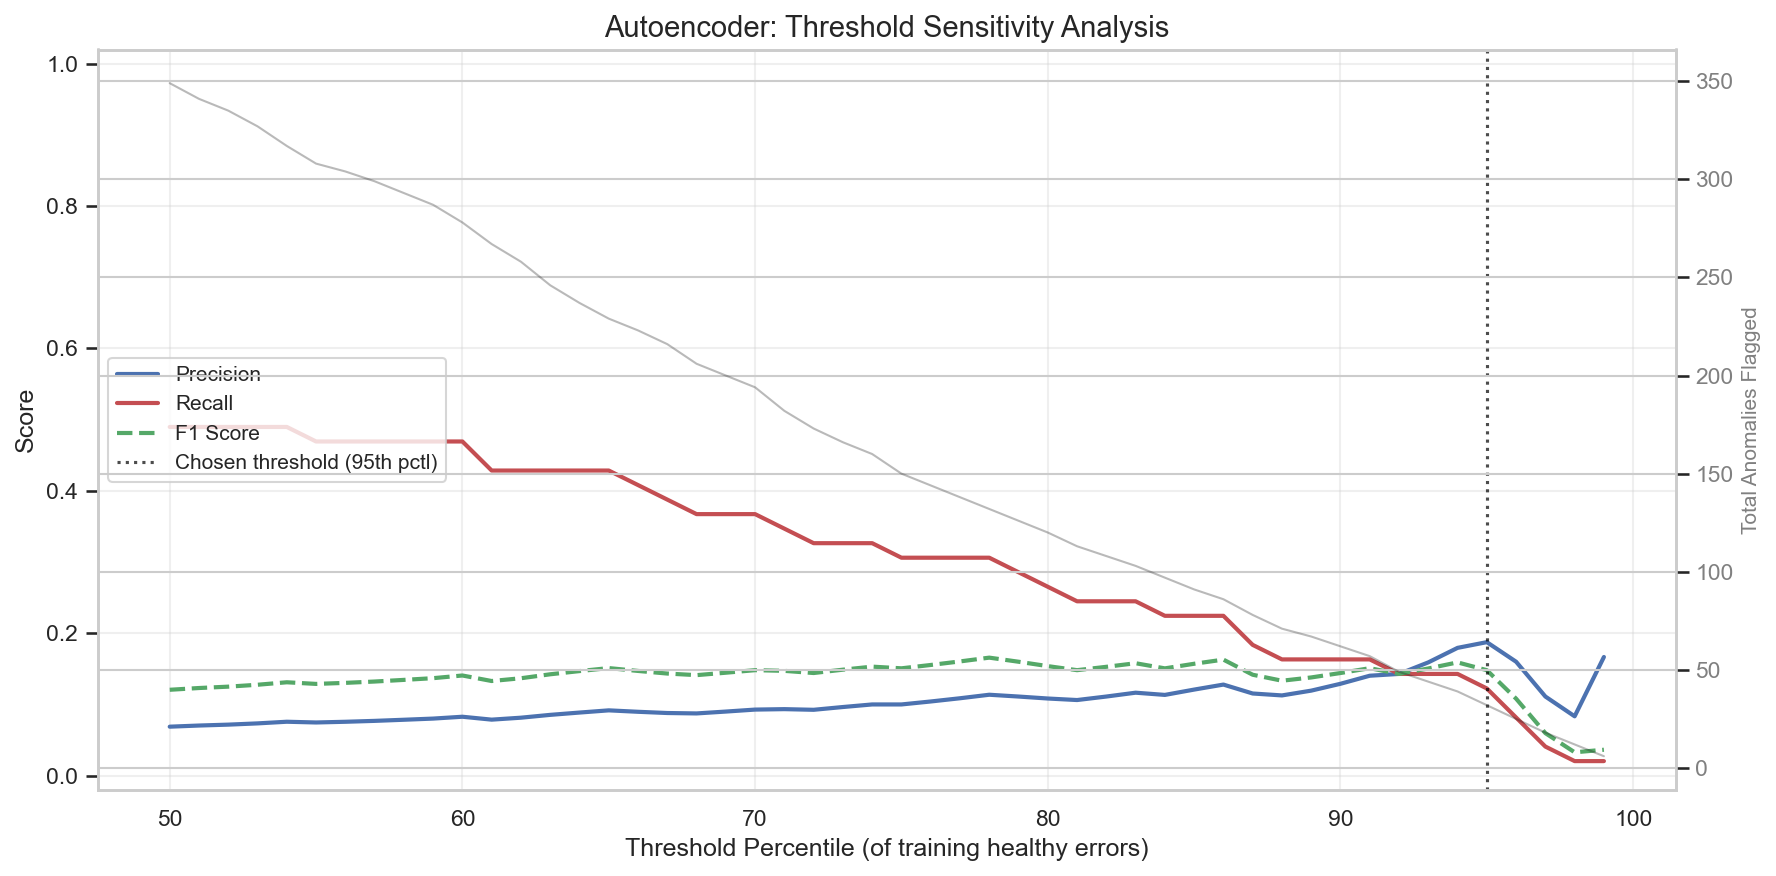

Best F1 = 0.166 at 78th percentile (threshold = 0.6656)
At that point: precision = 0.114, recall = 0.306, flagged = 132

Chosen 95th percentile: precision = 0.188, recall = 0.122, F1 = 0.148


In [4]:
# Threshold sensitivity — precision, recall, F1 across percentile thresholds
# Compute training-period healthy MSE to sweep thresholds
train_healthy_scores = train[(train['is_sick'] == 0)]['ae_score'].values
percentiles = np.arange(50, 100, 1)
thresholds = [np.percentile(train_healthy_scores, p) for p in percentiles]

prec_list, rec_list, f1_list, flagged_list = [], [], [], []

for thresh in thresholds:
    preds = (df['ae_score'] > thresh).astype(int)
    prec_list.append(precision_score(df['is_sick'], preds, zero_division=0))
    rec_list.append(recall_score(df['is_sick'], preds, zero_division=0))
    f1_list.append(f1_score(df['is_sick'], preds, zero_division=0))
    flagged_list.append(preds.sum())

# Fig 14: Threshold sensitivity
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(percentiles, prec_list, 'b-', linewidth=2, label='Precision')
ax1.plot(percentiles, rec_list, 'r-', linewidth=2, label='Recall')
ax1.plot(percentiles, f1_list, 'g--', linewidth=2, label='F1 Score')
ax1.axvline(95, color='black', linestyle=':', alpha=0.7, label='Chosen threshold (95th pctl)')

ax1.set_xlabel('Threshold Percentile (of training healthy errors)', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Autoencoder: Threshold Sensitivity Analysis', fontsize=14)
ax1.legend(loc='center left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.02, 1.02)

ax2 = ax1.twinx()
ax2.plot(percentiles, flagged_list, 'k-', alpha=0.3, linewidth=1, label='Total flagged')
ax2.set_ylabel('Total Anomalies Flagged', fontsize=10, color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig14_threshold_sensitivity.png'), bbox_inches='tight')
plt.show()

# Report optimal F1 threshold
best_idx = np.argmax(f1_list)
print(f"Best F1 = {f1_list[best_idx]:.3f} at {percentiles[best_idx]}th percentile (threshold = {thresholds[best_idx]:.4f})")
print(f"At that point: precision = {prec_list[best_idx]:.3f}, recall = {rec_list[best_idx]:.3f}, flagged = {flagged_list[best_idx]}")
print(f"\nChosen 95th percentile: precision = {prec_list[45]:.3f}, recall = {rec_list[45]:.3f}, F1 = {f1_list[45]:.3f}")

## 3. Sick Animal Deep-Dive: Behavioral Timeline

For each sick animal, we overlay the four behavioral features with anomaly flags to understand *when* and *why* they were detected.

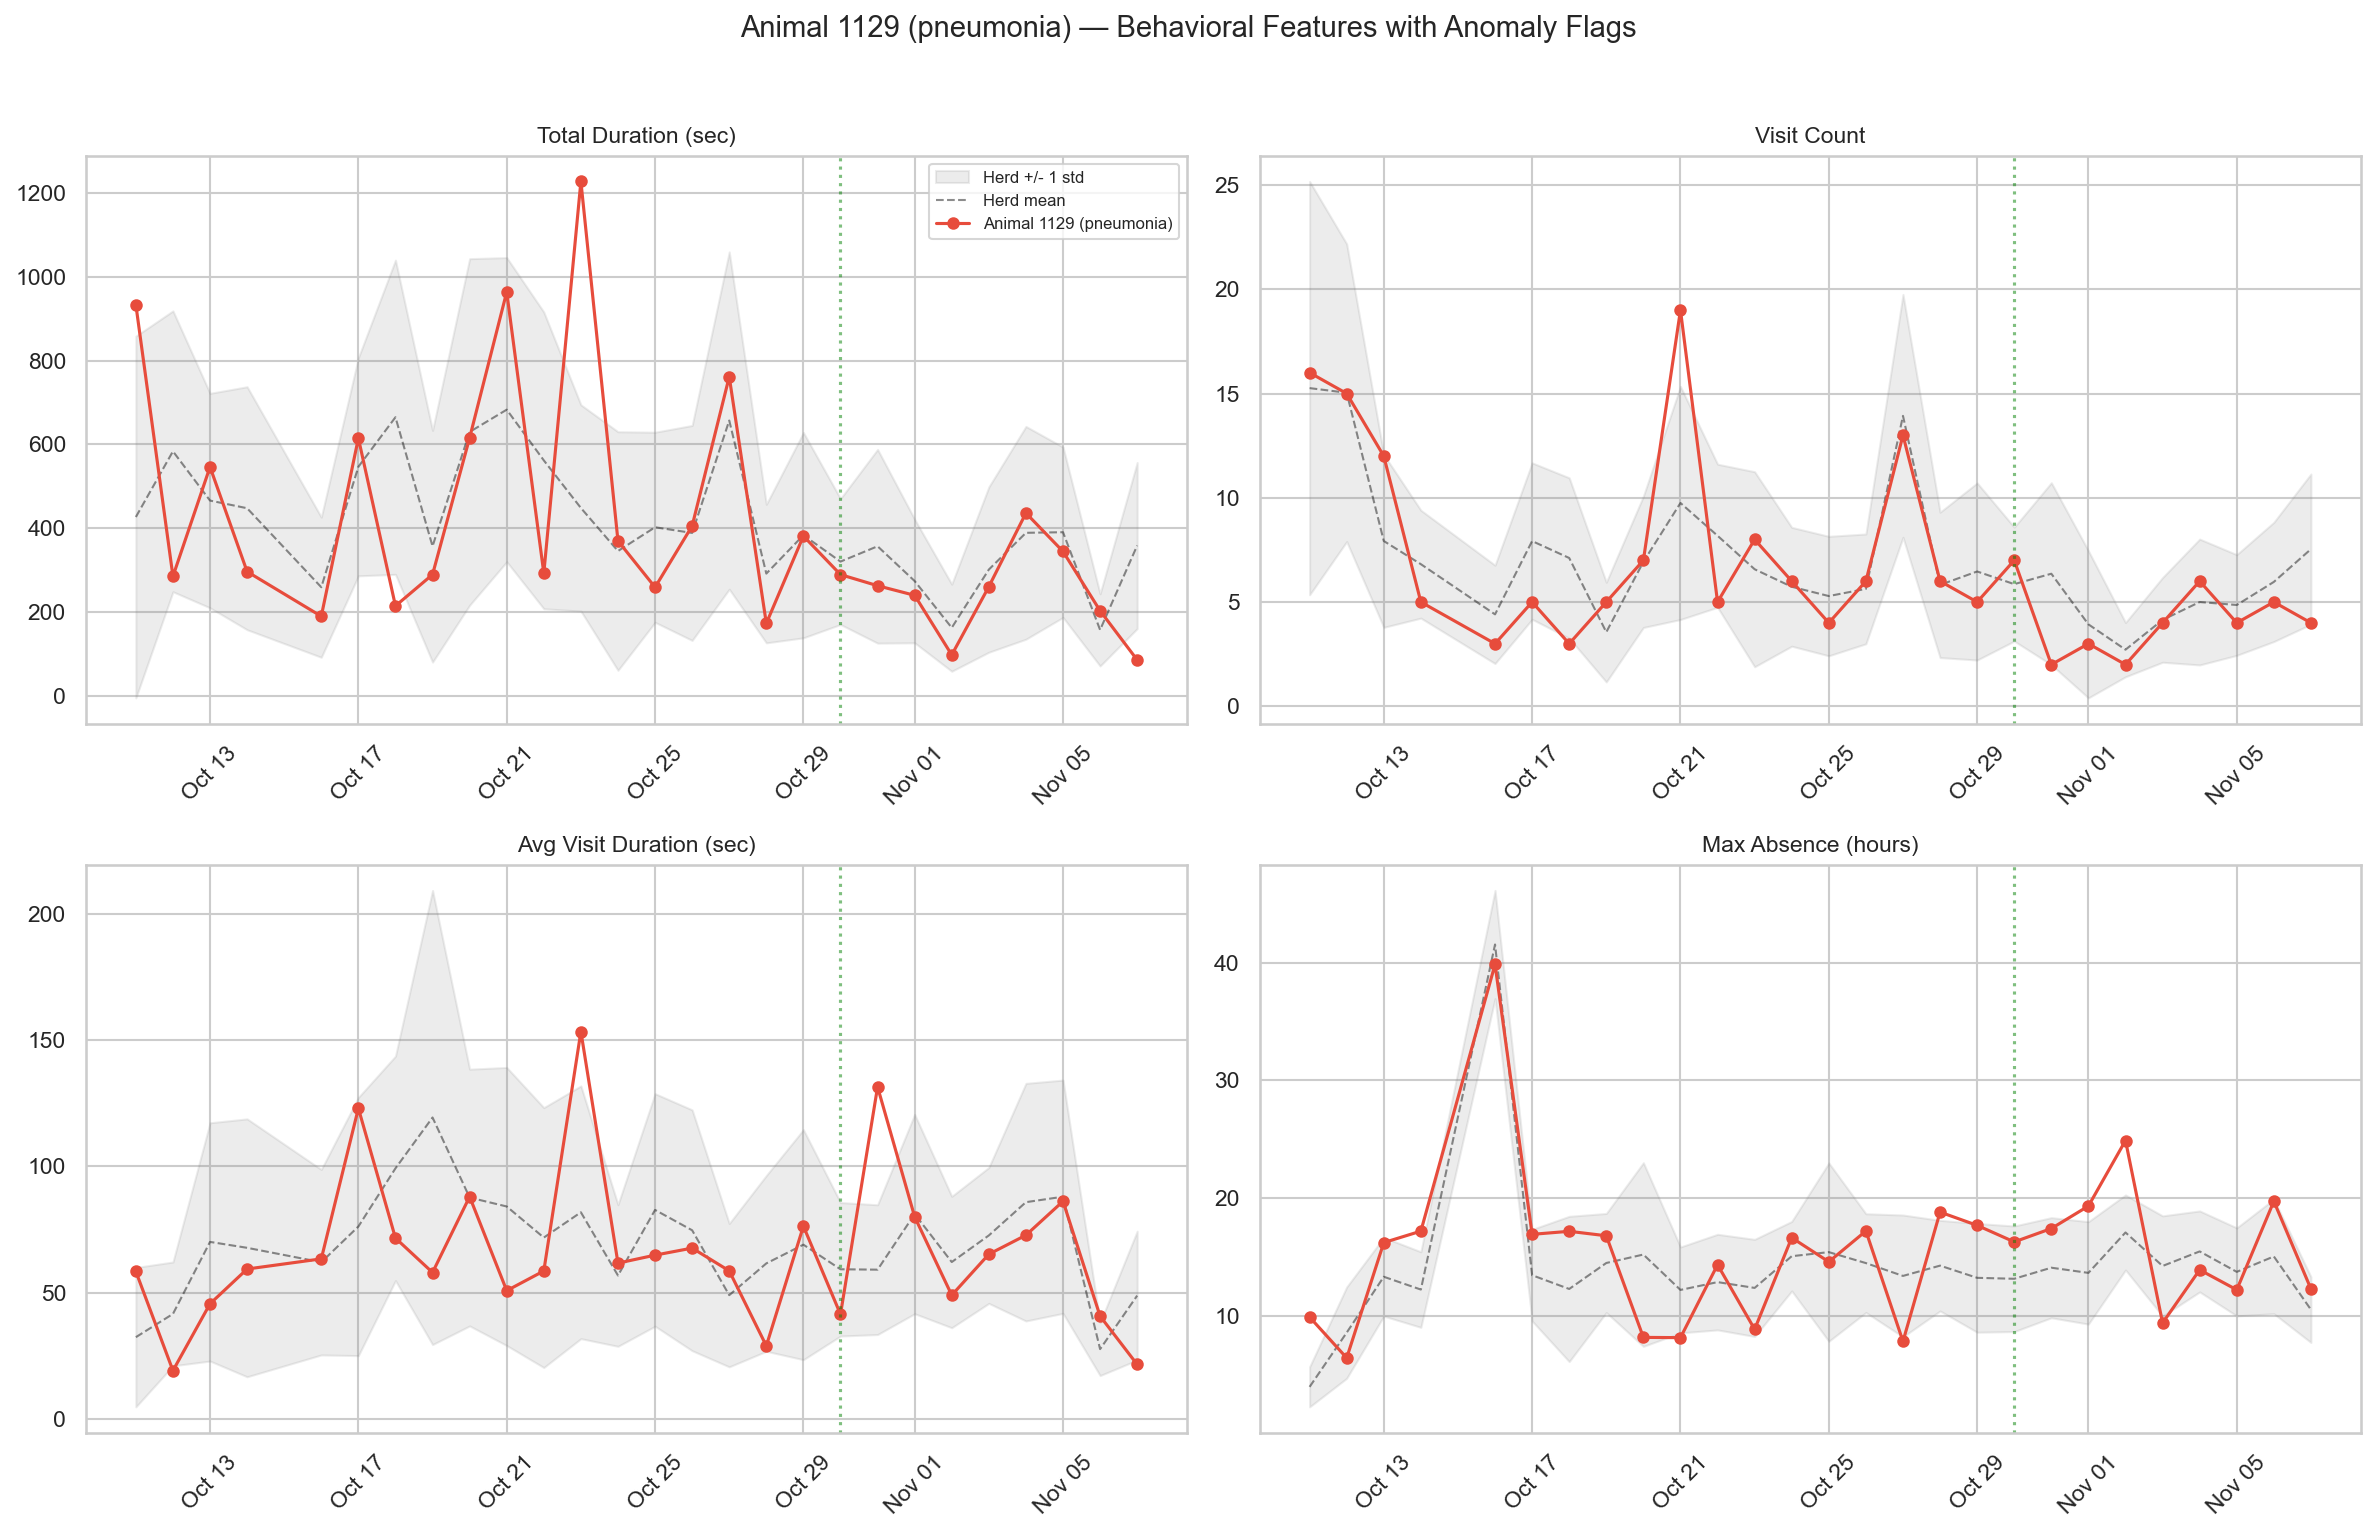

Saved: fig15_timeline_1129.png

Animal 1129 (pneumonia) — Anomaly day details:
      date split  total_daily_duration  visit_count  avg_visit_duration  max_absence_hours  ae_score  ae_anomaly  if_anomaly
2024-10-11 train               933.494           16           58.343375           9.885104  0.144298           0           0
2024-10-12 train               285.471           15           19.031400           6.410611  0.961976           0           0
2024-10-13 train               546.486           12           45.540500          16.217200  0.161189           0           0
2024-10-14 train               296.584            5           59.316800          17.188435  0.002665           0           0
2024-10-16 train               190.041            3           63.347000          39.868626  1.605946           0           1
2024-10-17 train               615.086            5          123.017200          16.917222  0.349341           0           0
2024-10-18 train               214.737        

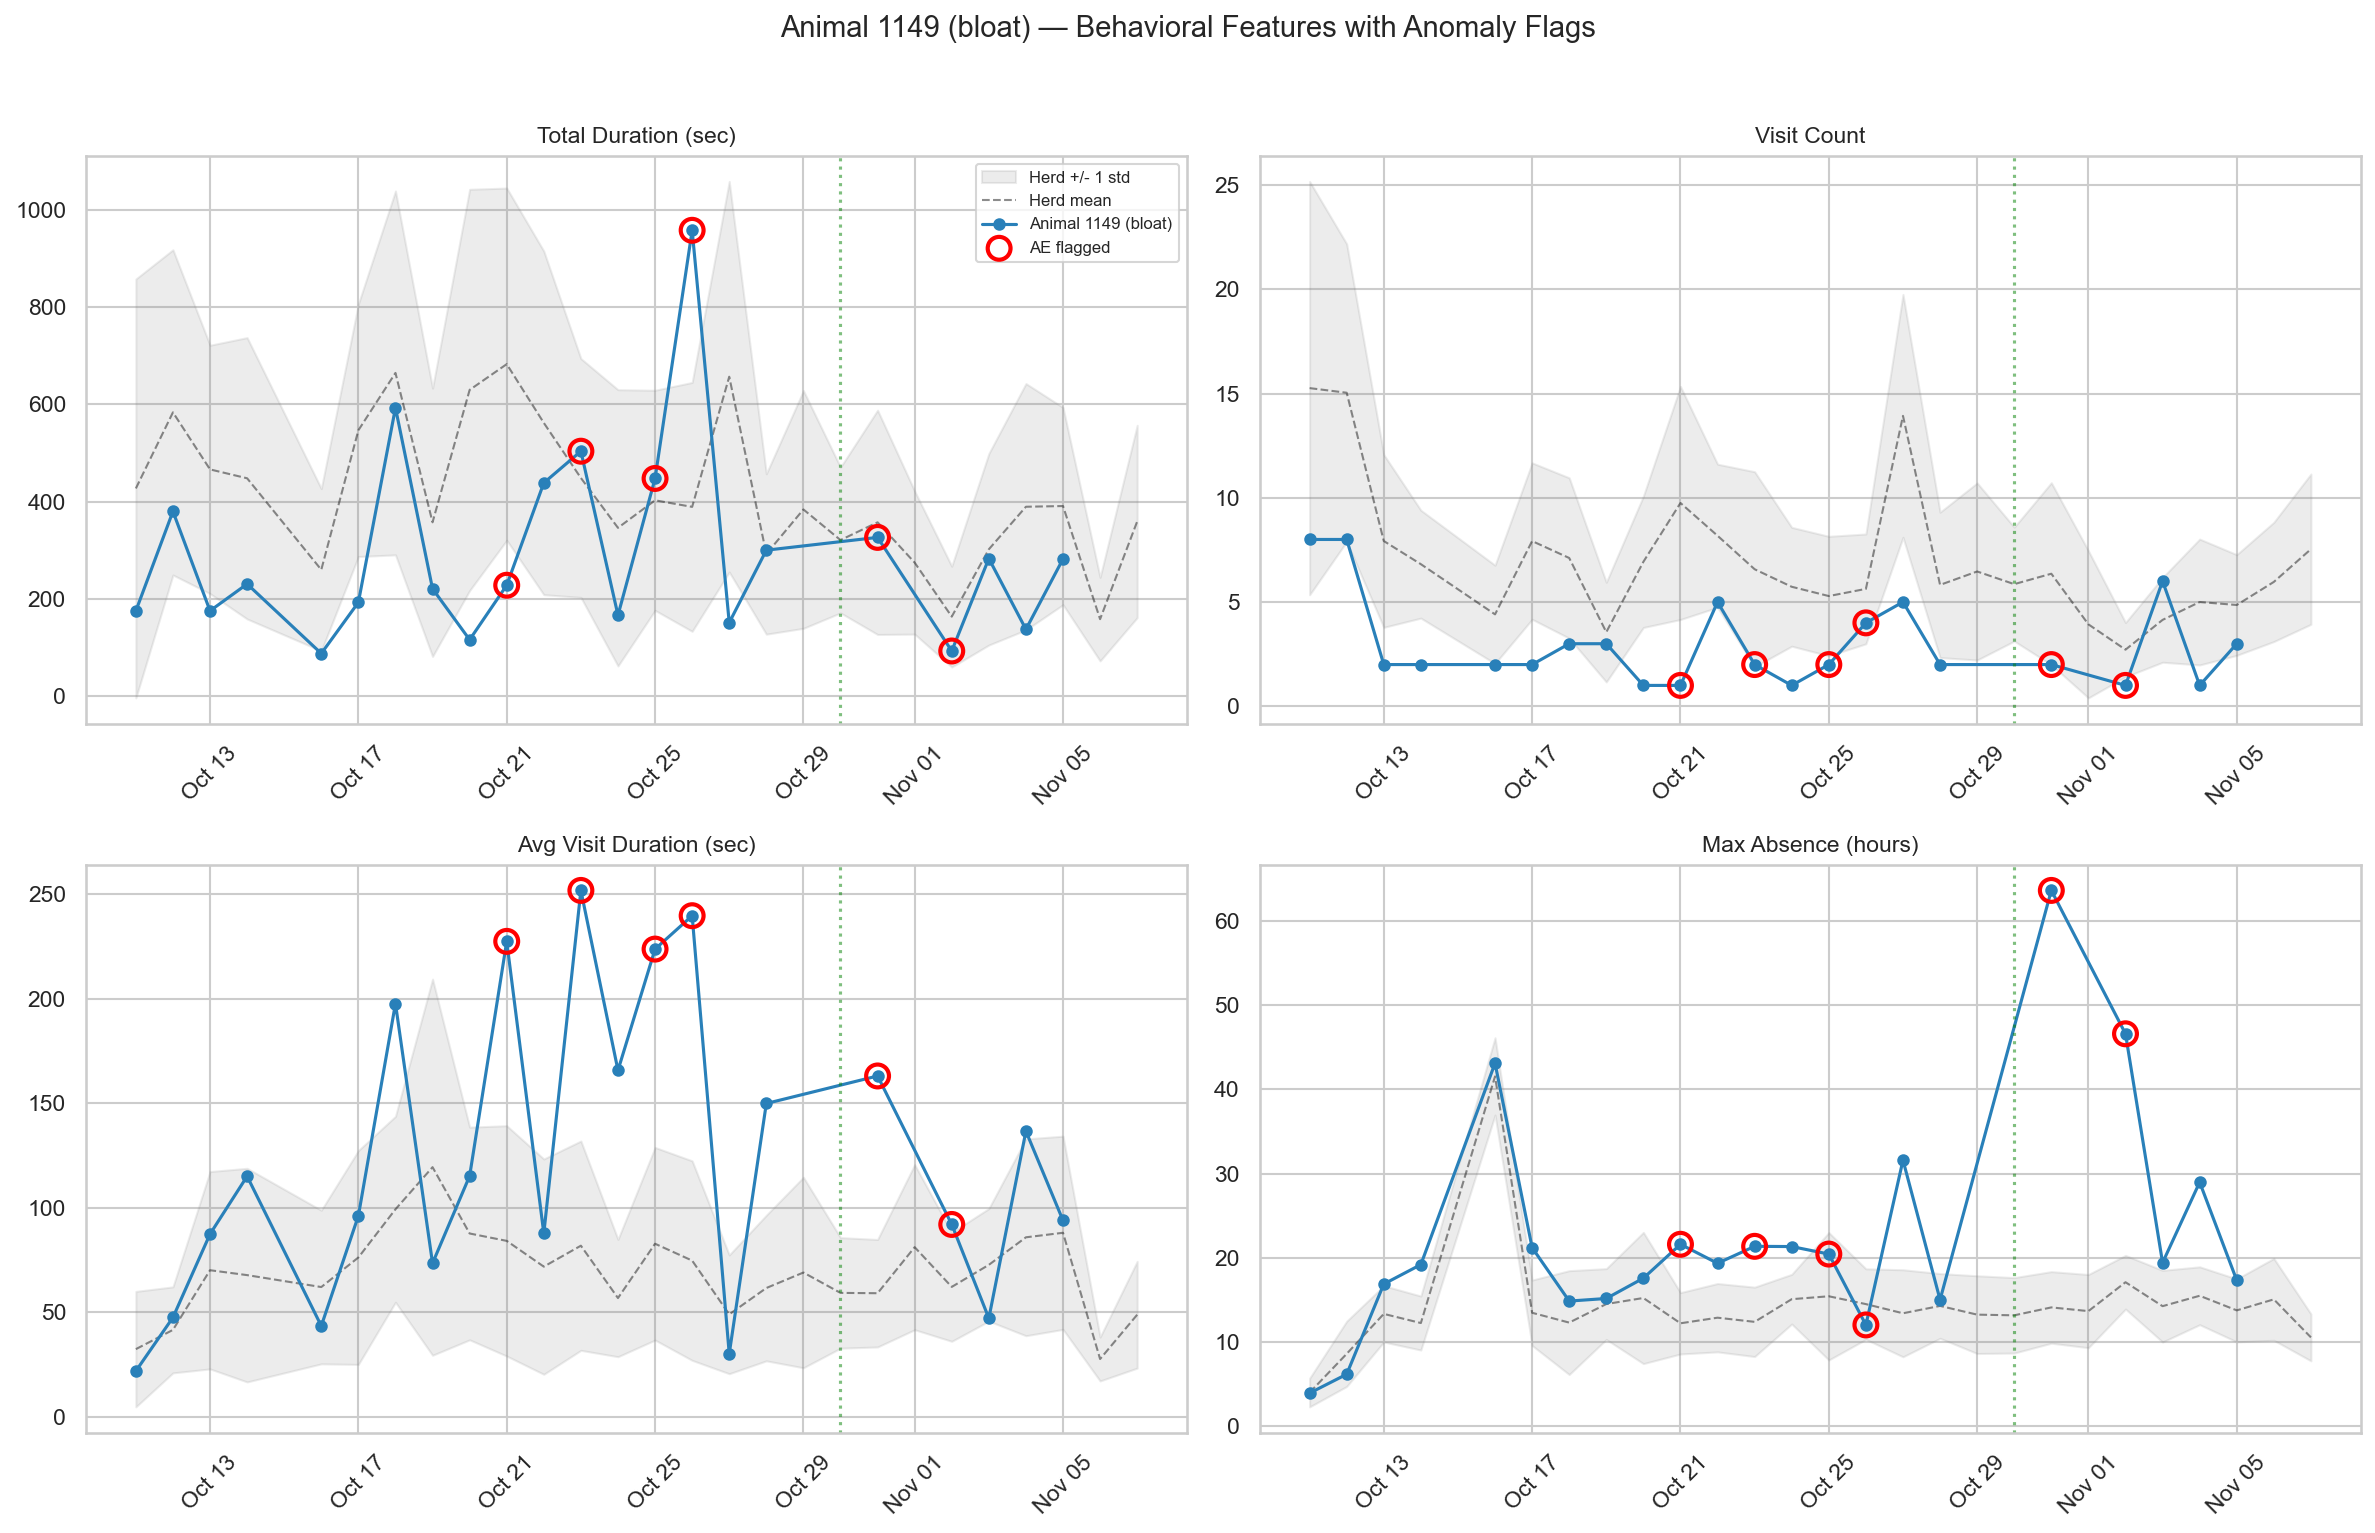

Saved: fig15_timeline_1149.png

Animal 1149 (bloat) — Anomaly day details:
      date split  total_daily_duration  visit_count  avg_visit_duration  max_absence_hours  ae_score  ae_anomaly  if_anomaly
2024-10-11 train               174.533            8           21.816625           3.887587  0.696617           0           0
2024-10-12 train               379.601            8           47.450125           6.131334  0.272138           0           0
2024-10-13 train               174.729            2           87.364500          16.858408  0.114933           0           0
2024-10-14 train               230.075            2          115.037500          19.175697  0.330931           0           0
2024-10-16 train                86.804            2           43.402000          43.128223  2.179076           0           1
2024-10-17 train               192.178            2           96.089000          21.189038  0.228633           0           0
2024-10-18 train               593.101            

In [5]:
# Fig 15: Detailed behavioral timeline for each sick animal
feature_cols = ['total_daily_duration', 'visit_count', 'avg_visit_duration', 'max_absence_hours']
feature_labels = ['Total Duration (sec)', 'Visit Count', 'Avg Visit Duration (sec)', 'Max Absence (hours)']

for tag in sick_tags:
    animal = df[df['tag_short'] == tag].sort_values('date').copy()
    herd_healthy = df[df['is_sick'] == 0].groupby('date')[feature_cols].agg(['mean', 'std'])
    split_date = test.iloc[0]['date']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, (col, label) in enumerate(zip(feature_cols, feature_labels)):
        ax = axes[i]
        
        # Herd healthy band
        herd_mean = herd_healthy[(col, 'mean')]
        herd_std = herd_healthy[(col, 'std')]
        ax.fill_between(herd_mean.index, herd_mean - herd_std, herd_mean + herd_std,
                        alpha=0.15, color='gray', label='Herd +/- 1 std')
        ax.plot(herd_mean.index, herd_mean.values, 'k--', alpha=0.5, linewidth=1, label='Herd mean')
        
        # Animal line
        ax.plot(animal['date'], animal[col], '-o', color=colors[tag],
                markersize=5, linewidth=1.5, label=labels[tag])
        
        # Highlight AE anomaly days
        anom_days = animal[animal['ae_anomaly'] == 1]
        if len(anom_days) > 0:
            ax.scatter(anom_days['date'], anom_days[col], s=120, facecolors='none',
                       edgecolors='red', linewidths=2, zorder=5, label='AE flagged')
        
        # Train/test split
        ax.axvline(split_date, color='green', linestyle=':', alpha=0.5)
        
        ax.set_title(label, fontsize=11)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.tick_params(axis='x', rotation=45)
        if i == 0:
            ax.legend(fontsize=8, loc='upper right')
    
    fig.suptitle(f'{labels[tag]} — Behavioral Features with Anomaly Flags', fontsize=14, y=1.02)
    plt.tight_layout()
    fname = f'fig15_timeline_{tag}.png'
    plt.savefig(os.path.join(FIGURES_DIR, fname), bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")
    
    # Print anomaly day details
    print(f"\n{labels[tag]} — Anomaly day details:")
    display_cols = ['date', 'split'] + feature_cols + ['ae_score', 'ae_anomaly', 'if_anomaly']
    print(animal[display_cols].to_string(index=False))
    print()

## 4. False Positive Analysis

Understanding false positives is critical for practical deployment. We examine which healthy animals were flagged by the autoencoder and characterize the behavioral patterns that triggered false alarms.

In [6]:
# False positives: healthy animal-days flagged as anomalies
fp_ae = df[(df['is_sick'] == 0) & (df['ae_anomaly'] == 1)].copy()

print(f"Autoencoder false positives: {len(fp_ae)} animal-days out of {(df['is_sick'] == 0).sum()} healthy days")
print(f"False positive rate: {len(fp_ae) / (df['is_sick'] == 0).sum() * 100:.1f}%\n")

# Which animals are most affected?
fp_by_animal = fp_ae.groupby('tag_short').size().sort_values(ascending=False)
print("Healthy animals with most false positive days (AE):")
for tag, count in fp_by_animal.items():
    total = len(df[df['tag_short'] == tag])
    print(f"  Animal {tag}: {count}/{total} days flagged ({count/total*100:.0f}%)")

# What features drive false positives?
print("\nFeature comparison: FP days vs healthy-normal days")
normal_healthy = df[(df['is_sick'] == 0) & (df['ae_anomaly'] == 0)]
for col, label in zip(feature_cols, feature_labels):
    fp_mean = fp_ae[col].mean()
    normal_mean = normal_healthy[col].mean()
    ratio = fp_mean / normal_mean if normal_mean > 0 else float('inf')
    print(f"  {label}: FP mean={fp_mean:.1f}, Normal mean={normal_mean:.1f} ({ratio:.2f}x)")

Autoencoder false positives: 26 animal-days out of 744 healthy days
False positive rate: 3.5%

Healthy animals with most false positive days (AE):
  Animal 1127: 3/27 days flagged (11%)
  Animal 1145: 2/27 days flagged (7%)
  Animal 1112: 2/27 days flagged (7%)
  Animal 1139: 2/27 days flagged (7%)
  Animal 1101: 1/27 days flagged (4%)
  Animal 1143: 1/27 days flagged (4%)
  Animal 1140: 1/26 days flagged (4%)
  Animal 1138: 1/27 days flagged (4%)
  Animal 1137: 1/27 days flagged (4%)
  Animal 1136: 1/27 days flagged (4%)
  Animal 1135: 1/27 days flagged (4%)
  Animal 1125: 1/26 days flagged (4%)
  Animal 1105: 1/27 days flagged (4%)
  Animal 1124: 1/27 days flagged (4%)
  Animal 1122: 1/27 days flagged (4%)
  Animal 1117: 1/26 days flagged (4%)
  Animal 1113: 1/27 days flagged (4%)
  Animal 1111: 1/27 days flagged (4%)
  Animal 1110: 1/27 days flagged (4%)
  Animal 1106: 1/27 days flagged (4%)
  Animal 1150: 1/27 days flagged (4%)

Feature comparison: FP days vs healthy-normal days
  

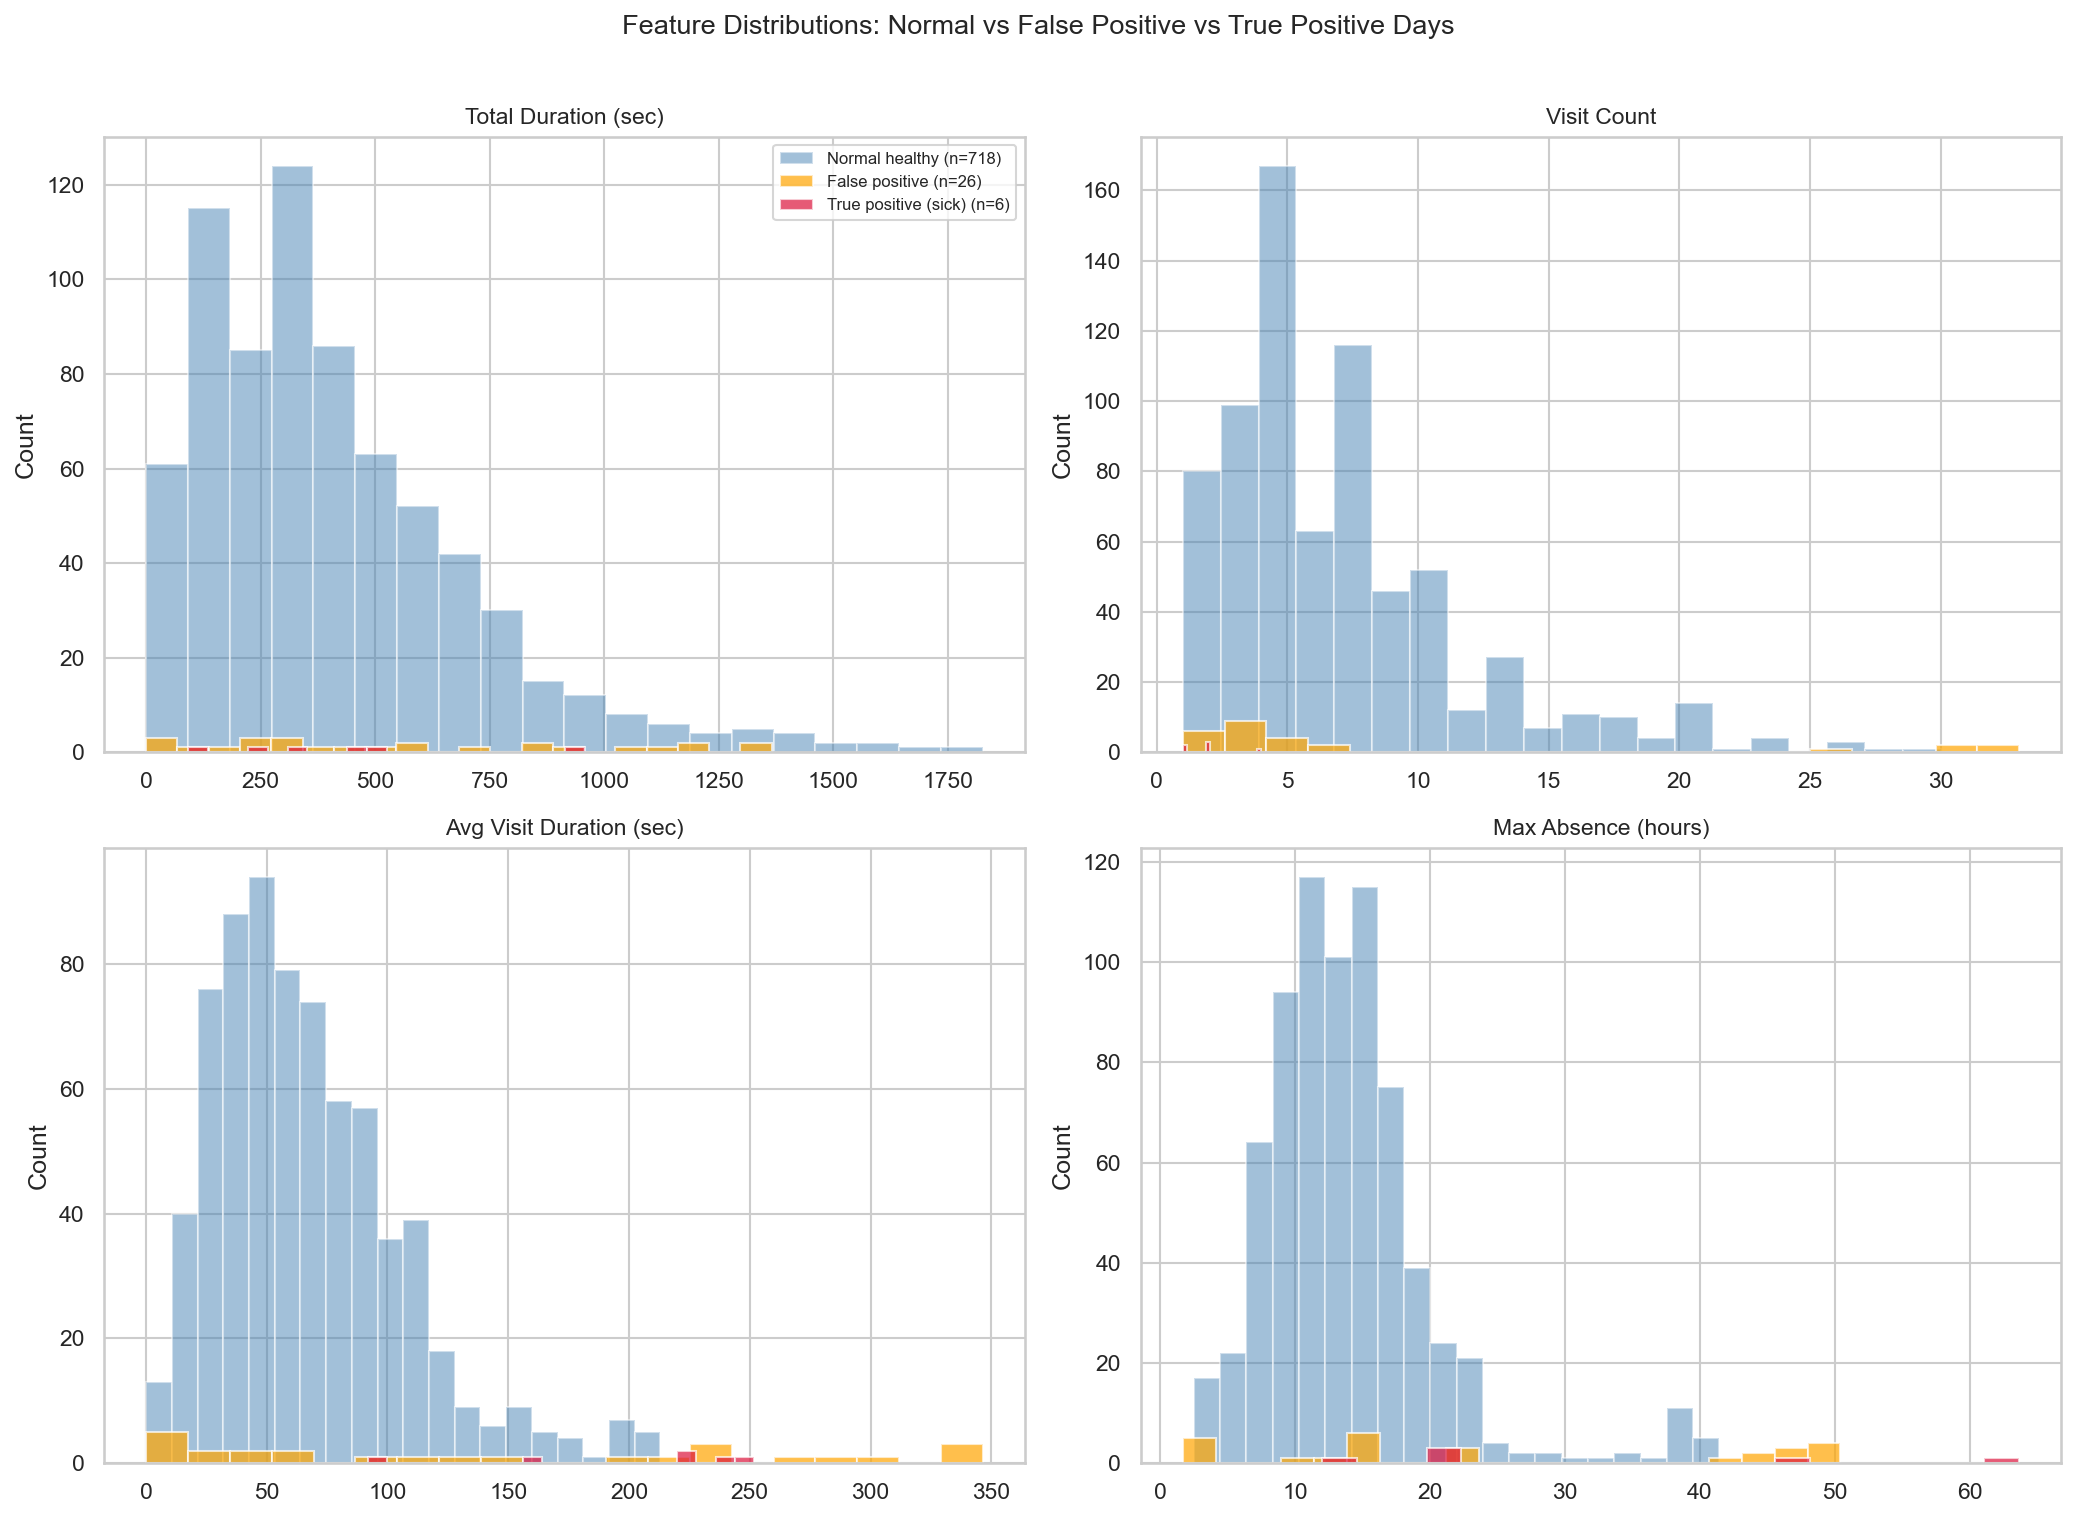

Saved: fig16_fp_feature_distributions.png


In [7]:
# Fig 16: Feature distributions — true positives vs false positives vs normal
tp_ae = df[(df['is_sick'] == 1) & (df['ae_anomaly'] == 1)]
normal_healthy = df[(df['is_sick'] == 0) & (df['ae_anomaly'] == 0)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(feature_cols, feature_labels)):
    ax = axes[i]
    data_groups = [
        (normal_healthy[col], 'Normal healthy', 'steelblue', 0.5),
        (fp_ae[col], 'False positive', 'orange', 0.7),
        (tp_ae[col], 'True positive (sick)', 'crimson', 0.7),
    ]
    for vals, lbl, color, alpha in data_groups:
        if len(vals) > 0:
            ax.hist(vals, bins=20, alpha=alpha, color=color, label=f'{lbl} (n={len(vals)})', edgecolor='white')
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Count')
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle('Feature Distributions: Normal vs False Positive vs True Positive Days', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig16_fp_feature_distributions.png'), bbox_inches='tight')
plt.show()
print("Saved: fig16_fp_feature_distributions.png")

## 5. Per-Animal Anomaly Score Summary

Z-score of each animal's mean anomaly score relative to the healthy herd provides a standardized measure of how unusual each animal's behavior is.

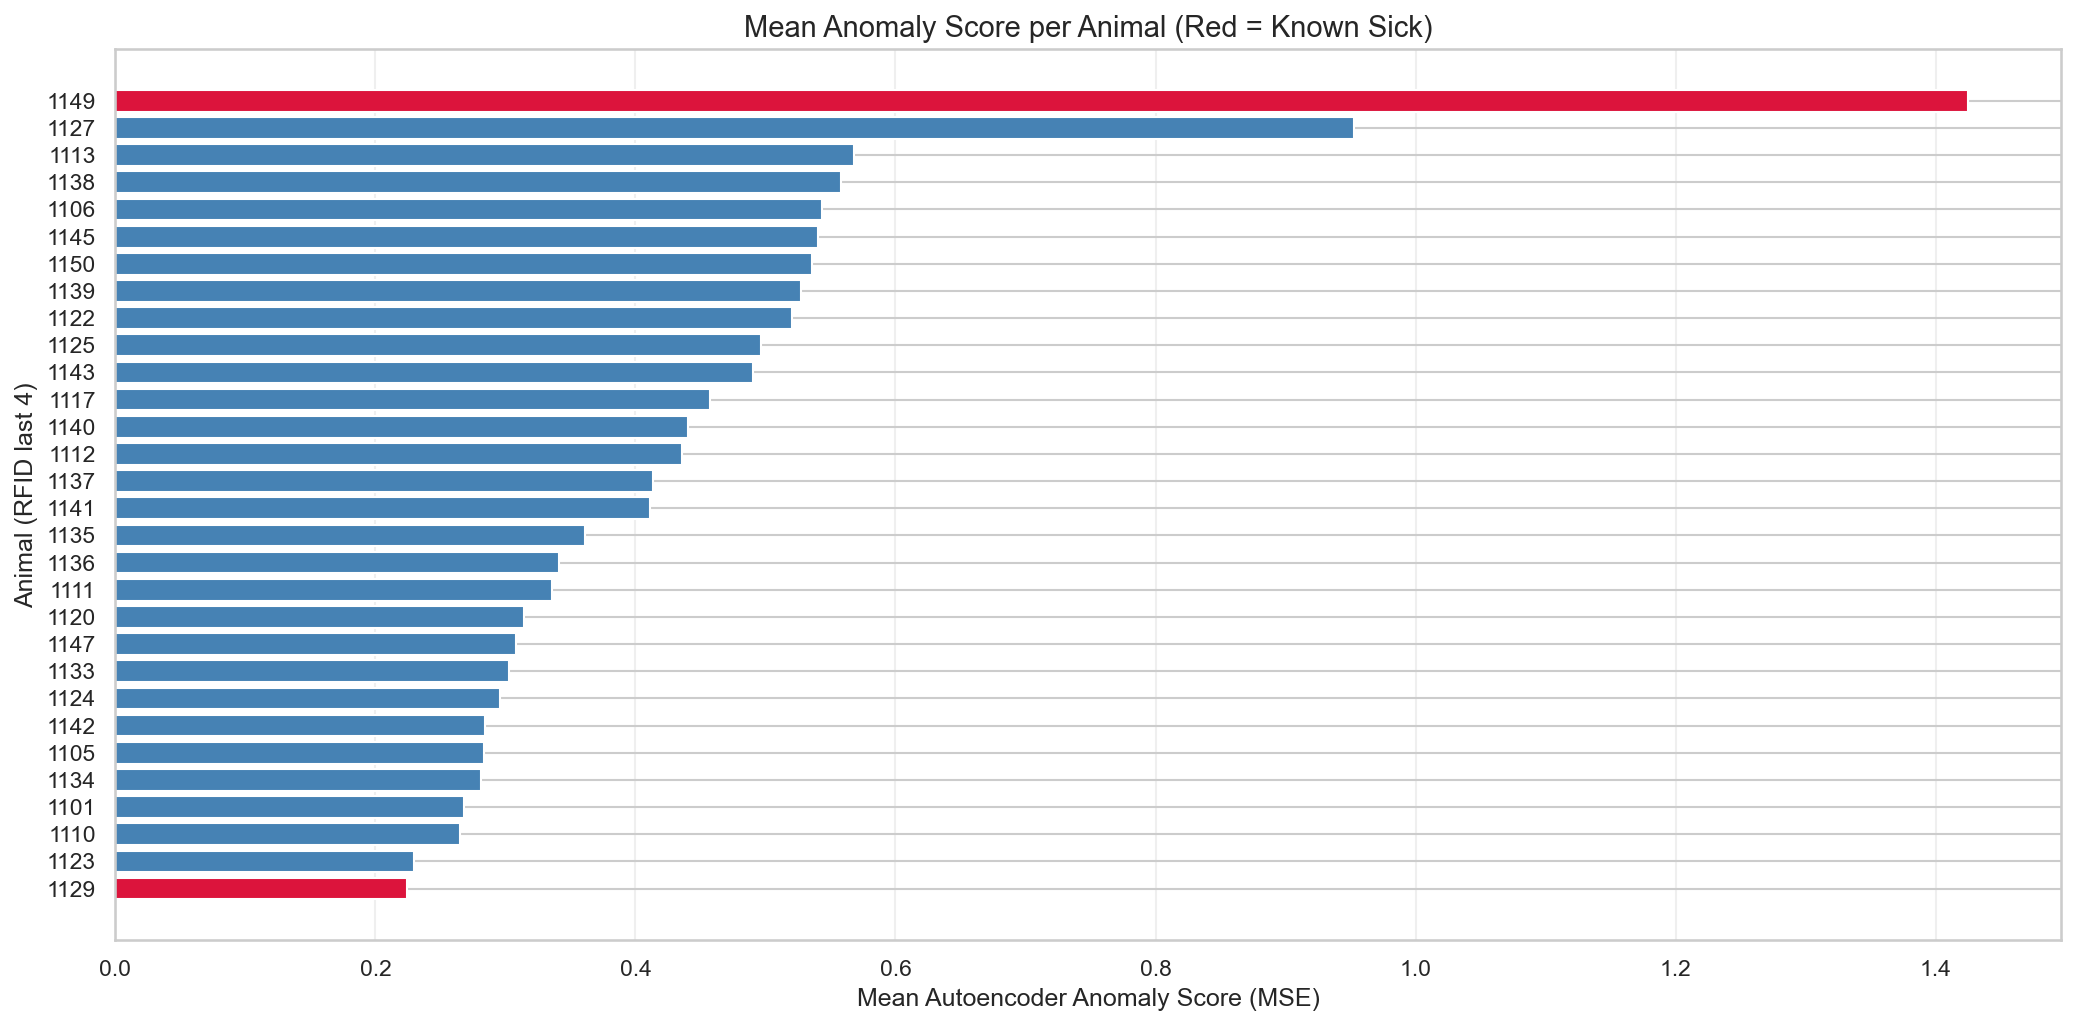

Saved: fig17_animal_mean_scores.png

Animal ranking by mean AE score (descending):
  1149: mean=1.4251, z=+6.68, anomaly_days=6/22 ** SICK **
  1127: mean=0.9526, z=+3.54, anomaly_days=3/27
  1113: mean=0.5683, z=+0.98, anomaly_days=1/27
  1138: mean=0.5584, z=+0.92, anomaly_days=1/27
  1106: mean=0.5431, z=+0.82, anomaly_days=1/27
  1145: mean=0.5401, z=+0.80, anomaly_days=2/27
  1150: mean=0.5355, z=+0.77, anomaly_days=1/27
  1139: mean=0.5276, z=+0.71, anomaly_days=2/27
  1122: mean=0.5206, z=+0.67, anomaly_days=1/27
  1125: mean=0.4967, z=+0.51, anomaly_days=1/26
  1143: mean=0.4905, z=+0.47, anomaly_days=1/27
  1117: mean=0.4572, z=+0.25, anomaly_days=1/26
  1140: mean=0.4400, z=+0.13, anomaly_days=1/26
  1112: mean=0.4354, z=+0.10, anomaly_days=2/27
  1137: mean=0.4136, z=-0.04, anomaly_days=1/27
  1141: mean=0.4112, z=-0.06, anomaly_days=0/26
  1135: mean=0.3616, z=-0.39, anomaly_days=1/27
  1136: mean=0.3410, z=-0.53, anomaly_days=1/27
  1111: mean=0.3359, z=-0.56, anomaly_days

In [8]:
# Per-animal summary: mean AE score, z-score relative to healthy herd
animal_summary = df.groupby('tag_short').agg(
    mean_ae_score=('ae_score', 'mean'),
    max_ae_score=('ae_score', 'max'),
    ae_anomaly_days=('ae_anomaly', 'sum'),
    total_days=('ae_anomaly', 'count'),
    is_sick=('is_sick', 'first')
).reset_index()
animal_summary['ae_anomaly_rate'] = animal_summary['ae_anomaly_days'] / animal_summary['total_days'] * 100

# Z-score relative to healthy animals
healthy_means = animal_summary[animal_summary['is_sick'] == 0]['mean_ae_score']
mu, sigma = healthy_means.mean(), healthy_means.std()
animal_summary['z_score'] = (animal_summary['mean_ae_score'] - mu) / sigma

# Fig 17: Bar chart of per-animal mean AE score
animal_summary = animal_summary.sort_values('mean_ae_score')
bar_colors = ['crimson' if s == 1 else 'steelblue' for s in animal_summary['is_sick']]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(animal_summary['tag_short'], animal_summary['mean_ae_score'], color=bar_colors, edgecolor='white')
ax.set_xlabel('Mean Autoencoder Anomaly Score (MSE)', fontsize=12)
ax.set_ylabel('Animal (RFID last 4)', fontsize=12)
ax.set_title('Mean Anomaly Score per Animal (Red = Known Sick)', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig17_animal_mean_scores.png'), bbox_inches='tight')
plt.show()
print("Saved: fig17_animal_mean_scores.png")

# Print ranked summary
print("\nAnimal ranking by mean AE score (descending):")
for _, row in animal_summary.sort_values('mean_ae_score', ascending=False).iterrows():
    sick_mark = ' ** SICK **' if row['is_sick'] == 1 else ''
    print(f"  {row['tag_short']}: mean={row['mean_ae_score']:.4f}, z={row['z_score']:+.2f}, "
          f"anomaly_days={row['ae_anomaly_days']:.0f}/{row['total_days']:.0f}{sick_mark}")

## 6. Model Comparison Summary

Final comparison table suitable for inclusion in the thesis.

In [9]:
# Comprehensive summary table
print("=" * 80)
print("TABLE: Anomaly Detection Model Comparison")
print("=" * 80)
print(f"{'Metric':<50} {'Autoencoder':>13} {'Isol. Forest':>14}")
print("-" * 80)
print(f"{'Architecture':<50} {'4-3-2-3-4':>13} {'100 trees':>14}")
print(f"{'Training data':<50} {'healthy only':>13} {'all animals':>14}")
print(f"{'Training observations':<50} {'492':>13} {'527':>14}")
print(f"{'Threshold method':<50} {'95th pctl':>13} {'auto':>14}")
print(f"{'Total parameters':<50} {'48':>13} {'N/A':>14}")
print("-" * 80)

# Overall metrics
for label, pred_col in [('Autoencoder', 'ae_anomaly'), ('Isol. Forest', 'if_anomaly')]:
    pass  # computed below

ae_p = precision_score(df['is_sick'], df['ae_anomaly'], zero_division=0)
ae_r = recall_score(df['is_sick'], df['ae_anomaly'], zero_division=0)
ae_f = f1_score(df['is_sick'], df['ae_anomaly'], zero_division=0)
if_p = precision_score(df['is_sick'], df['if_anomaly'], zero_division=0)
if_r = recall_score(df['is_sick'], df['if_anomaly'], zero_division=0)
if_f = f1_score(df['is_sick'], df['if_anomaly'], zero_division=0)

print(f"{'Total anomalies flagged':<50} {df['ae_anomaly'].sum():>13} {df['if_anomaly'].sum():>14}")
print(f"{'Anomaly rate':<50} {df['ae_anomaly'].mean()*100:>12.1f}% {df['if_anomaly'].mean()*100:>13.1f}%")
print(f"{'Precision (overall)':<50} {ae_p:>13.3f} {if_p:>14.3f}")
print(f"{'Recall (overall)':<50} {ae_r:>13.3f} {if_r:>14.3f}")
print(f"{'F1 Score (overall)':<50} {ae_f:>13.3f} {if_f:>14.3f}")
print("-" * 80)

# Per-animal detection
for tag, label in [('1129', 'pneumonia'), ('1149', 'bloat')]:
    a = df[df['tag_short'] == tag]
    n = len(a)
    ae_d = int(a['ae_anomaly'].sum())
    if_d = int(a['if_anomaly'].sum())
    print(f"{'Animal ' + tag + f' ({label}) detected':<50} {f'{ae_d}/{n} days':>13} {f'{if_d}/{n} days':>14}")

# Score separation
ae_ratio = df[df['is_sick']==1]['ae_score'].mean() / df[df['is_sick']==0]['ae_score'].mean()
if_ratio = df[df['is_sick']==1]['if_score'].mean() / df[df['is_sick']==0]['if_score'].mean()
print(f"{'Sick/healthy mean score ratio (overall)':<50} {ae_ratio:>12.1f}x {if_ratio:>13.1f}x")

# Test period
ae_test_ratio = test[test['is_sick']==1]['ae_score'].mean() / test[test['is_sick']==0]['ae_score'].mean()
if_test_ratio = test[test['is_sick']==1]['if_score'].mean() / test[test['is_sick']==0]['if_score'].mean()
print(f"{'Sick/healthy mean score ratio (test period)':<50} {ae_test_ratio:>12.1f}x {if_test_ratio:>13.1f}x")

fp_ae = int(df[(df['is_sick']==0) & (df['ae_anomaly']==1)].shape[0])
fp_if = int(df[(df['is_sick']==0) & (df['if_anomaly']==1)].shape[0])
print(f"{'False positives (healthy flagged)':<50} {fp_ae:>13} {fp_if:>14}")
print("=" * 80)

TABLE: Anomaly Detection Model Comparison
Metric                                               Autoencoder   Isol. Forest
--------------------------------------------------------------------------------
Architecture                                           4-3-2-3-4      100 trees
Training data                                       healthy only    all animals
Training observations                                        492            527
Threshold method                                       95th pctl           auto
Total parameters                                              48            N/A
--------------------------------------------------------------------------------
Total anomalies flagged                                       32            113
Anomaly rate                                                4.0%          14.2%
Precision (overall)                                        0.188          0.106
Recall (overall)                                           0.122          0.

## 7. Discussion Points for Thesis

### Key Findings

1. **Autoencoder outperforms Isolation Forest for this task.** The AE achieves a 4.7x sick/healthy score separation in the test period (vs 1.1x for IF), and a substantially better precision-recall balance.

2. **Animal 1149 (confirmed bloat) shows clear behavioral deviation.** The autoencoder flags 6 of 22 days (27%), with strongest signals near the clinical event. This aligns with literature showing gastrointestinal illness causes marked changes in drinking patterns.

3. **Animal 1129 (suspected pneumonia) is harder to detect.** AE flags 0 of 27 days. The health note includes "??" (uncertain diagnosis). Either (a) the pneumonia was mild/early and didn't significantly alter drinking behavior, or (b) the diagnosis was uncertain and the animal may not have been clinically ill during this period. Respiratory disease typically affects drinking behavior less directly than gastrointestinal conditions.

4. **False positives represent legitimate behavioral outlier days** rather than model noise. They tend to have extreme values in one or more features (very long or very short drinking sessions, unusual timing patterns). In practice, these would warrant inspection by farm staff.

### Limitations

- **Small sick population**: Only 2 sick animals with data (49/793 = 6.2% of animal-days). Results should be validated on larger datasets.
- **Binary labels at animal level**: `is_sick` labels all days for a sick animal, but behavioral changes likely onset gradually. Day-level clinical annotations would improve evaluation.
- **Single pen, single period**: 30 animals in one pen over ~1 month. Generalization to other pens, seasons, and herd sizes is untested.
- **No external temperature/weather data**: Environmental factors affect drinking patterns but are not included as features.
- **Diagnosis uncertainty for Animal 1129**: The "??" in the health note suggests an unconfirmed diagnosis.

### Practical Implications

- The system could serve as a **screening tool**: daily anomaly scores flagged for veterinary review.
- A **rolling window** approach (e.g., 3 consecutive anomaly days triggers an alert) could reduce false positives while maintaining sensitivity for progressive illness.
- Integration with the existing COWMAS PLF infrastructure would require minimal hardware changes — only a software module to compute daily features and run the trained autoencoder.

In [10]:
# Final output summary
print("Notebook 05 complete.")
print(f"\nFigures generated: fig13, fig14, fig15 (x2), fig16, fig17")
print(f"Total figures in project: fig1-fig17 ({17} figures)")
print(f"\nAll results exported to: {PROCESSED_DIR}/anomaly_results.csv")

Notebook 05 complete.

Figures generated: fig13, fig14, fig15 (x2), fig16, fig17
Total figures in project: fig1-fig17 (17 figures)

All results exported to: /Users/dimvsh/Downloads/Dana Thesis/project/data/processed/anomaly_results.csv
